In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os
from PIL import Image
from sklearn.model_selection import train_test_split

Paths to the folders containing the images

In [ ]:
birds= Path("dataset/bird")
drones= Path("dataset/drone")


Remove .png files and edit .jpeg to .jpg (if file exists with same name, then remove)

In [19]:
for file in os.listdir(birds):
    if file.endswith('.png'):
        os.remove(os.path.join(birds,file))
    if file.endswith('.jpeg'):
        new_path=os.path.join(birds,file[:-5]+'.jpg')
        if os.path.exists(new_path):
            os.remove(os.path.join(birds,file))
        else:
            os.rename(os.path.join(birds,file),new_path)

for file in os.listdir(drones):
    if file.endswith('.png'):
        os.remove(os.path.join(drones,file))
    if file.endswith('.jpeg'):
        new_path=os.path.join(drones,file[:-5]+'.jpg')
        if os.path.exists(new_path):
            os.remove(os.path.join(birds,file))
        else: 
            os.rename(os.path.join(drones,file),new_path)



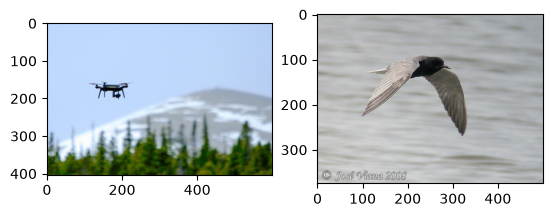

In [23]:
#check first image from both

fig, axes = plt.subplots(1, 2)

axes[0].imshow(Image.open(os.path.join(drones, os.listdir(drones)[0])))


axes[1].imshow(Image.open(os.path.join(birds, os.listdir(birds)[0])))

In [24]:
#Load data into X and y (convert images to matrixes, resize and convert to rgb)

XValues=[]
yValues=[]

for file in os.listdir(drones):
    if file.endswith('.jpg'):
        img= Image.open(os.path.join(drones,file)).resize((224,224)).convert('RGB')
        XValues.append(np.asarray(img))
        yValues.append(0)

for file in os.listdir(birds):
    if file.endswith('.jpg'):
        img= Image.open(os.path.join(birds,file)).resize((224,224)).convert('RGB')
        XValues.append(np.asarray(img))
        yValues.append(1)

X= np.array(XValues)
y= np.array(yValues)
        

In [25]:
#Normalize the X array from 255 to values 0-1
X=X/255

In [27]:
#Show first element of X matrix, shape and rgb values for first pixel

print(X[0])
print("Shape", X[0].shape)
print("RGB Values:", X[0][0, 0])

[[[0.73333333 0.84313725 0.99607843]
  [0.73333333 0.84313725 0.99607843]
  [0.73333333 0.84313725 0.99607843]
  ...
  [0.70980392 0.81176471 0.95686275]
  [0.70980392 0.81176471 0.95686275]
  [0.70980392 0.81176471 0.95686275]]

 [[0.73333333 0.84313725 0.99607843]
  [0.73333333 0.84313725 0.99607843]
  [0.73333333 0.84313725 0.99607843]
  ...
  [0.70980392 0.81176471 0.95686275]
  [0.70980392 0.81176471 0.95686275]
  [0.70980392 0.81176471 0.95686275]]

 [[0.73333333 0.84313725 0.99607843]
  [0.73333333 0.84313725 0.99607843]
  [0.73333333 0.84313725 0.99607843]
  ...
  [0.70980392 0.81176471 0.95686275]
  [0.70980392 0.81176471 0.95686275]
  [0.70980392 0.81176471 0.95686275]]

 ...

 [[0.12941176 0.29411765 0.        ]
  [0.14901961 0.26666667 0.00392157]
  [0.15294118 0.21960784 0.01176471]
  ...
  [0.25882353 0.36862745 0.00784314]
  [0.26666667 0.38431373 0.00784314]
  [0.26666667 0.38431373 0.        ]]

 [[0.16862745 0.29803922 0.        ]
  [0.19607843 0.2745098  0.00392157]


In [30]:
#crete splits (75%, 10% and 15%)

X_train, X_temp, y_train, y_temp = train_test_split(X, y,
    test_size=0.25,
    random_state=42
)


X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp,
    test_size=0.60,
    random_state=42
)
